In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt


✅ Both images loaded successfully!
Virat image size : (361, 384, 3)
Dhoni image size : (364, 313, 3)


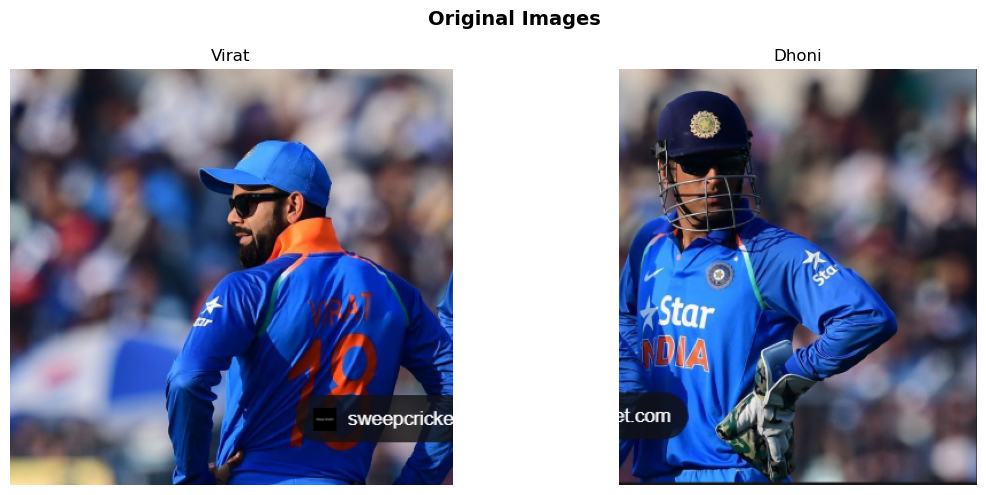

In [3]:

# Loading two images (Virat & Dhoni) to perform image addition
# Both images must be the same size for addition to work

# Load both images from disk in BGR format
virat = cv2.imread("virat.jpeg.png")
dhoni = cv2.imread("dhoni.jpeg.png")

# Check if both images loaded successfully
if virat is None:
    print("❌ virat.jpeg not found! Check the path.")
elif dhoni is None:
    print("❌ dhoni.jpeg not found! Check the path.")
else:
    print("✅ Both images loaded successfully!")
    print(f"Virat image size : {virat.shape}")
    print(f"Dhoni image size : {dhoni.shape}")

    # Convert BGR → RGB for correct color display in matplotlib
    virat_rgb = cv2.cvtColor(virat, cv2.COLOR_BGR2RGB)
    dhoni_rgb = cv2.cvtColor(dhoni, cv2.COLOR_BGR2RGB)

    # Display both original images
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(virat_rgb)
    plt.title("Virat")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(dhoni_rgb)
    plt.title("Dhoni")
    plt.axis('off')

    plt.suptitle("Original Images", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Virat resized : (500, 500, 3)
Dhoni resized : (500, 500, 3)


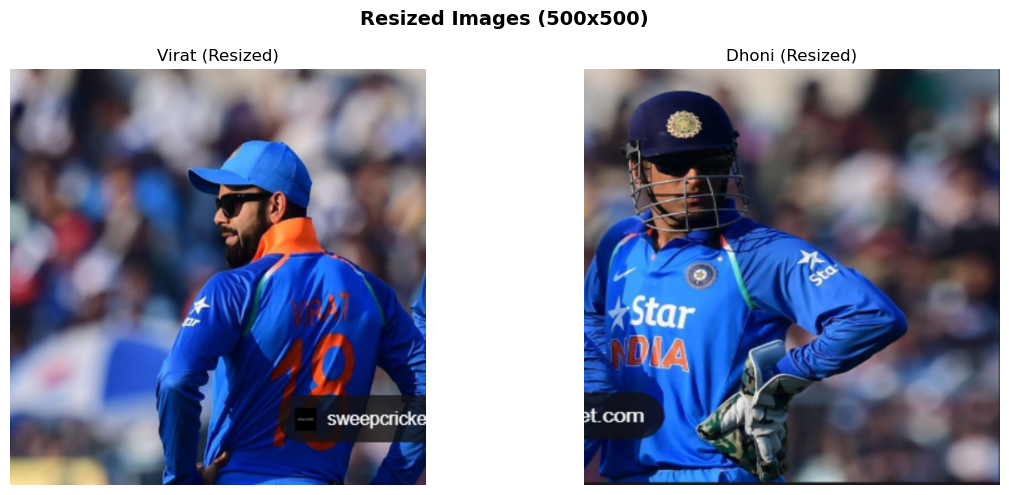

In [4]:
# ============================================================
# CELL 2: Resize Both Images to Same Size
# ============================================================
# Image addition requires BOTH images to be the exact same size
# We resize both to a fixed size (500x500) to ensure compatibility
# cv2.resize(image, (width, height))

target_size = (500, 500)

# Resize both images to same fixed dimensions
virat_resized = cv2.resize(virat, target_size)
dhoni_resized = cv2.resize(dhoni, target_size)

# Convert resized images to RGB for display
virat_resized_rgb = cv2.cvtColor(virat_resized, cv2.COLOR_BGR2RGB)
dhoni_resized_rgb = cv2.cvtColor(dhoni_resized, cv2.COLOR_BGR2RGB)

print(f"Virat resized : {virat_resized.shape}")
print(f"Dhoni resized : {dhoni_resized.shape}")

# Display resized images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(virat_resized_rgb)
plt.title("Virat (Resized)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dhoni_resized_rgb)
plt.title("Dhoni (Resized)")
plt.axis('off')

plt.suptitle("Resized Images (500x500)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

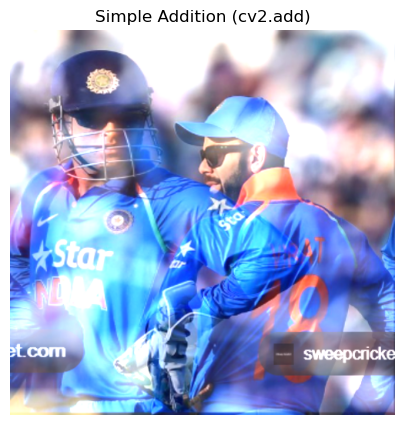

In [5]:
# ============================================================
# CELL 3: Simple Image Addition
# ============================================================
# cv2.add() adds pixel values of both images together
# Formula: result(x,y) = virat(x,y) + dhoni(x,y)
# Values are clipped at 255 (no overflow)
# Result may look bright/washed out due to high pixel values

added = cv2.add(virat_resized, dhoni_resized)

# Convert to RGB for display
added_rgb = cv2.cvtColor(added, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(added_rgb)
plt.title("Simple Addition (cv2.add)")
plt.axis('off')
plt.show()

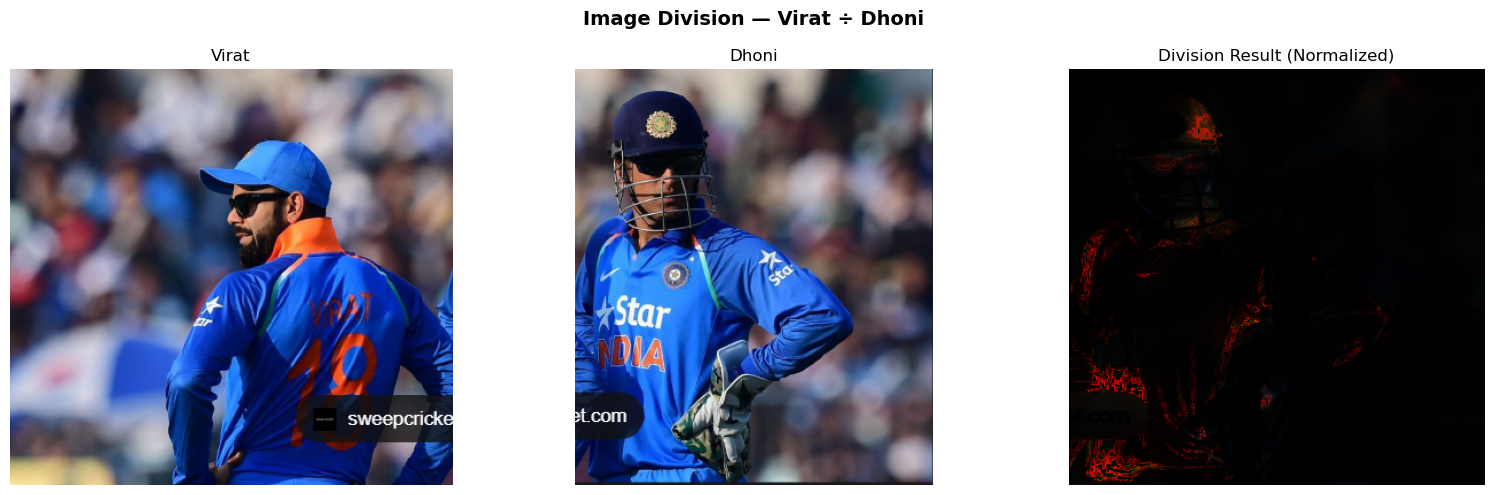

Virat   pixel range : 0 to 255
Dhoni   pixel range : 0 to 255
Divided pixel range : 0 to 255


In [6]:
# ============================================================
# CELL 4: Image Division
# ============================================================
# Divides pixel values of Virat by pixel values of Dhoni
# Formula : result(x,y) = virat(x,y) / dhoni(x,y)
# Division reveals the ratio between pixel intensities
# Areas where both images are similar → result close to 1 (dark)
# Areas where Virat is brighter than Dhoni → result > 1 (bright)
# NOTE: cv2.divide() handles division by zero safely (result = 0)
# Result is scaled to [0,255] using normalize for better visibility

# Perform division
divided = cv2.divide(virat_resized, dhoni_resized)

# Normalize result to [0,255] for proper display
# Raw division values are very small (0.0 to 1.0 range)
divided_normalized = cv2.normalize(divided, None,
                                   alpha=0, beta=255,
                                   norm_type=cv2.NORM_MINMAX,
                                   dtype=cv2.CV_8U)
divided_rgb = cv2.cvtColor(divided_normalized, cv2.COLOR_BGR2RGB)

# Display result
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(virat_rgb)
plt.title("Virat")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(dhoni_rgb)
plt.title("Dhoni")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(divided_rgb)
plt.title("Division Result (Normalized)")
plt.axis('off')

plt.suptitle("Image Division — Virat ÷ Dhoni", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Virat   pixel range : {virat_resized.min()} to {virat_resized.max()}")
print(f"Dhoni   pixel range : {dhoni_resized.min()} to {dhoni_resized.max()}")
print(f"Divided pixel range : {divided_normalized.min()} to {divided_normalized.max()}")

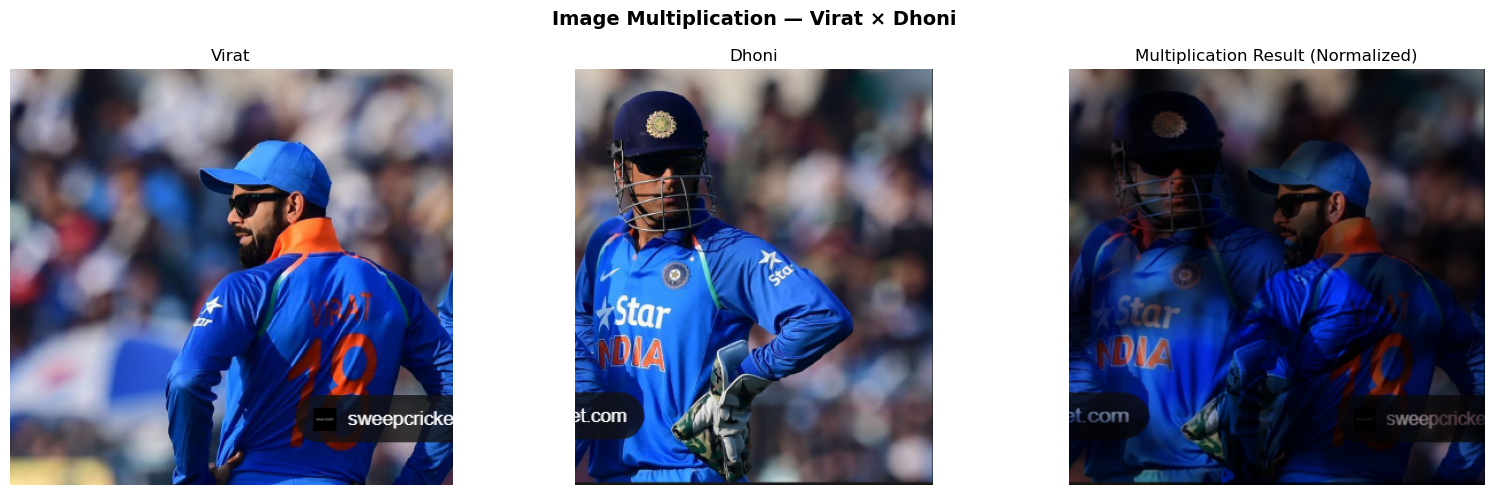

Virat       pixel range : 0 to 255
Dhoni       pixel range : 0 to 255
Multiplied  pixel range : 0 to 255


In [7]:
# ============================================================
# CELL 5: Image Multiplication
# ============================================================
# Multiplies pixel values of both images together
# Formula : result(x,y) = virat(x,y) × dhoni(x,y)
# Raw multiplication produces very large values (e.g. 200×200=40000)
# so we must normalize the result back to [0,255]
# Bright regions in BOTH images → very bright result
# Dark region in EITHER image  → dark result (near 0)
# Useful for masking — highlights only common bright regions

# Convert to float32 to avoid overflow during multiplication
virat_float = virat_resized.astype(np.float32)
dhoni_float = dhoni_resized.astype(np.float32)

# Perform multiplication
multiplied = cv2.multiply(virat_float, dhoni_float)

# Normalize result to [0,255] for proper display
multiplied_normalized = cv2.normalize(multiplied, None,
                                      alpha=0, beta=255,
                                      norm_type=cv2.NORM_MINMAX,
                                      dtype=cv2.CV_8U)
multiplied_rgb = cv2.cvtColor(multiplied_normalized, cv2.COLOR_BGR2RGB)

# Display result
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(virat_rgb)
plt.title("Virat")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(dhoni_rgb)
plt.title("Dhoni")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(multiplied_rgb)
plt.title("Multiplication Result (Normalized)")
plt.axis('off')

plt.suptitle("Image Multiplication — Virat × Dhoni", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Virat       pixel range : {virat_resized.min()} to {virat_resized.max()}")
print(f"Dhoni       pixel range : {dhoni_resized.min()} to {dhoni_resized.max()}")
print(f"Multiplied  pixel range : {multiplied_normalized.min()} to {multiplied_normalized.max()}")

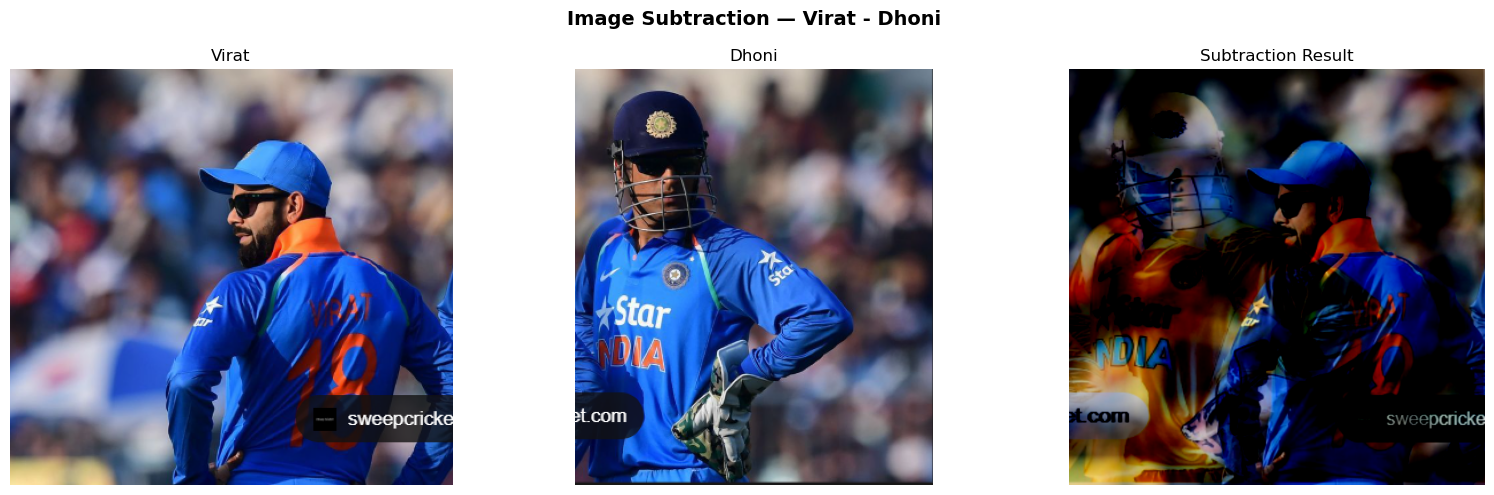

Virat      pixel range : 0 to 255
Dhoni      pixel range : 0 to 255
Subtracted pixel range : 0 to 247


In [8]:
# ============================================================
# CELL 6: Image Subtraction
# ============================================================
# Subtracts pixel values of Dhoni from Virat
# Formula : result(x,y) = virat(x,y) - dhoni(x,y)
# Highlights the DIFFERENCES between two images
# Areas where both images are similar → result close to 0 (dark)
# Areas where Virat is brighter than Dhoni → bright result
# cv2.subtract() clips negative values at 0 (no underflow)
# Useful for detecting changes or differences between two images

subtracted = cv2.subtract(virat_resized, dhoni_resized)
subtracted_rgb = cv2.cvtColor(subtracted, cv2.COLOR_BGR2RGB)

# Display result
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(virat_rgb)
plt.title("Virat")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(dhoni_rgb)
plt.title("Dhoni")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(subtracted_rgb)
plt.title("Subtraction Result")
plt.axis('off')

plt.suptitle("Image Subtraction — Virat - Dhoni", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Virat      pixel range : {virat_resized.min()} to {virat_resized.max()}")
print(f"Dhoni      pixel range : {dhoni_resized.min()} to {dhoni_resized.max()}")
print(f"Subtracted pixel range : {subtracted.min()} to {subtracted.max()}")

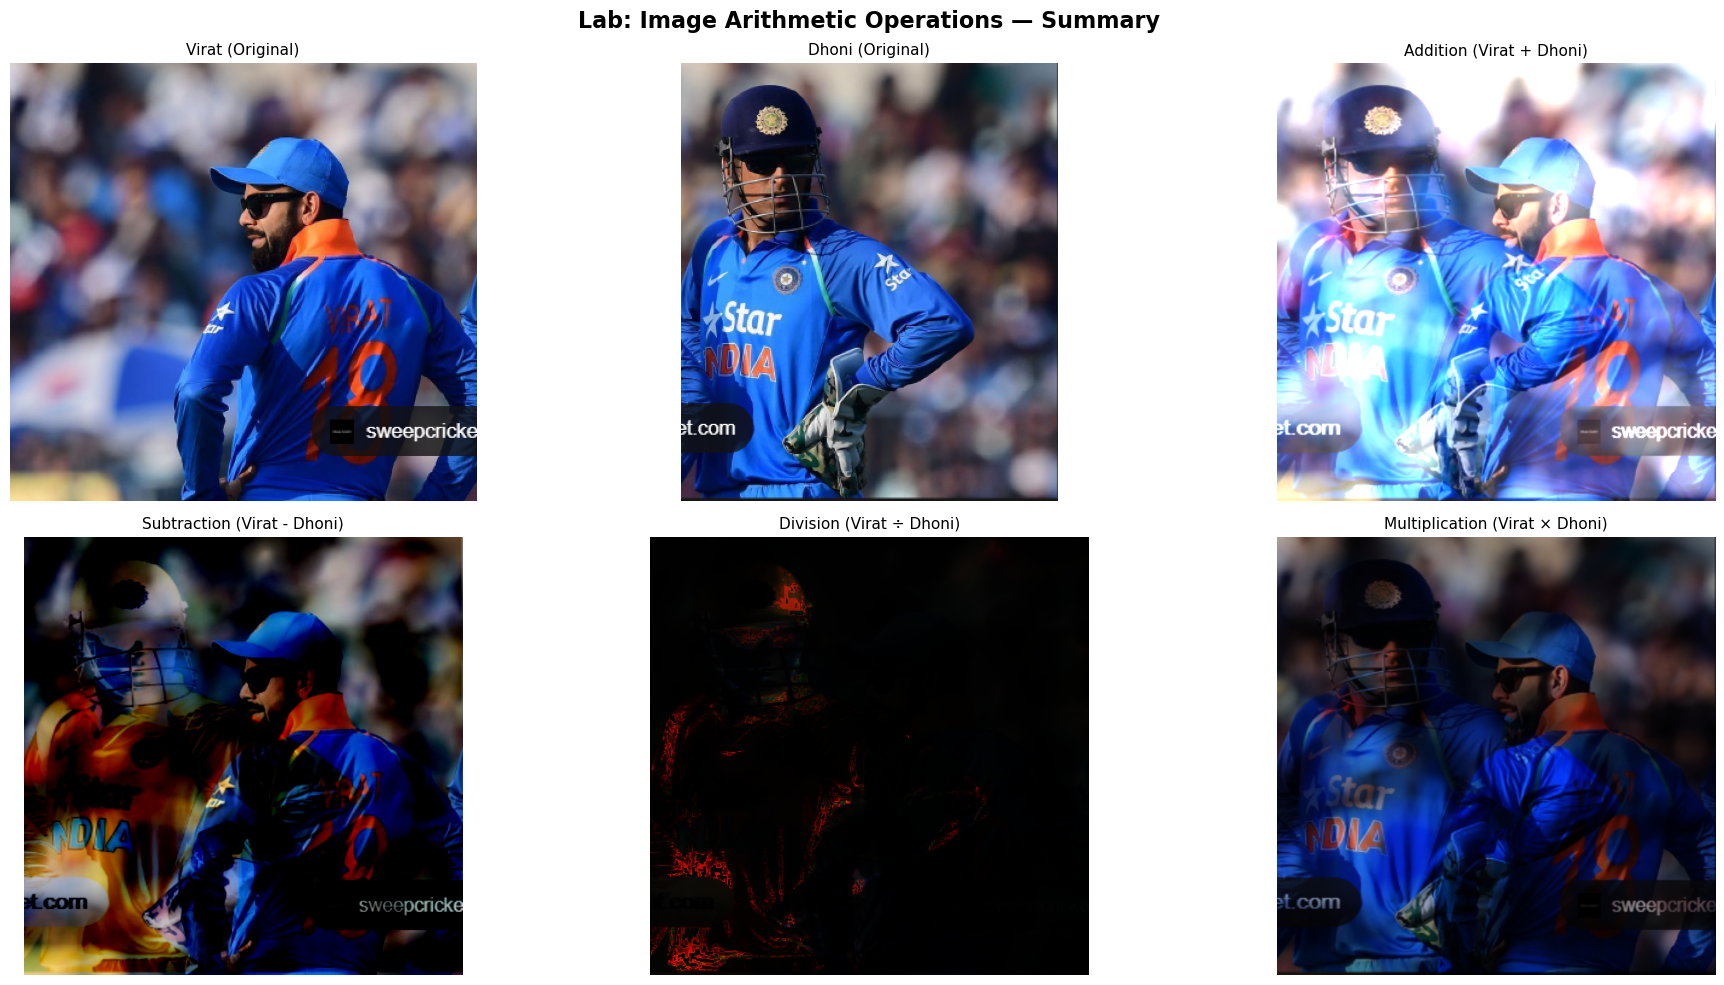

In [9]:
# ============================================================
# CELL 7: Summary — All Arithmetic Operations in One Figure
# ============================================================
# Displays all images and operation results in a single figure
# for easy side-by-side visual comparison of all operations

results = {
    "Virat (Original)"              : virat_rgb,
    "Dhoni (Original)"              : dhoni_rgb,
    "Addition (Virat + Dhoni)"      : added_rgb,
    "Subtraction (Virat - Dhoni)"   : subtracted_rgb,
    "Division (Virat ÷ Dhoni)"      : divided_rgb,
    "Multiplication (Virat × Dhoni)": multiplied_rgb,
}

plt.figure(figsize=(20, 10))

for i, (title, img) in enumerate(results.items()):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(title, fontsize=11)
    plt.axis('off')

plt.suptitle("Lab: Image Arithmetic Operations — Summary",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

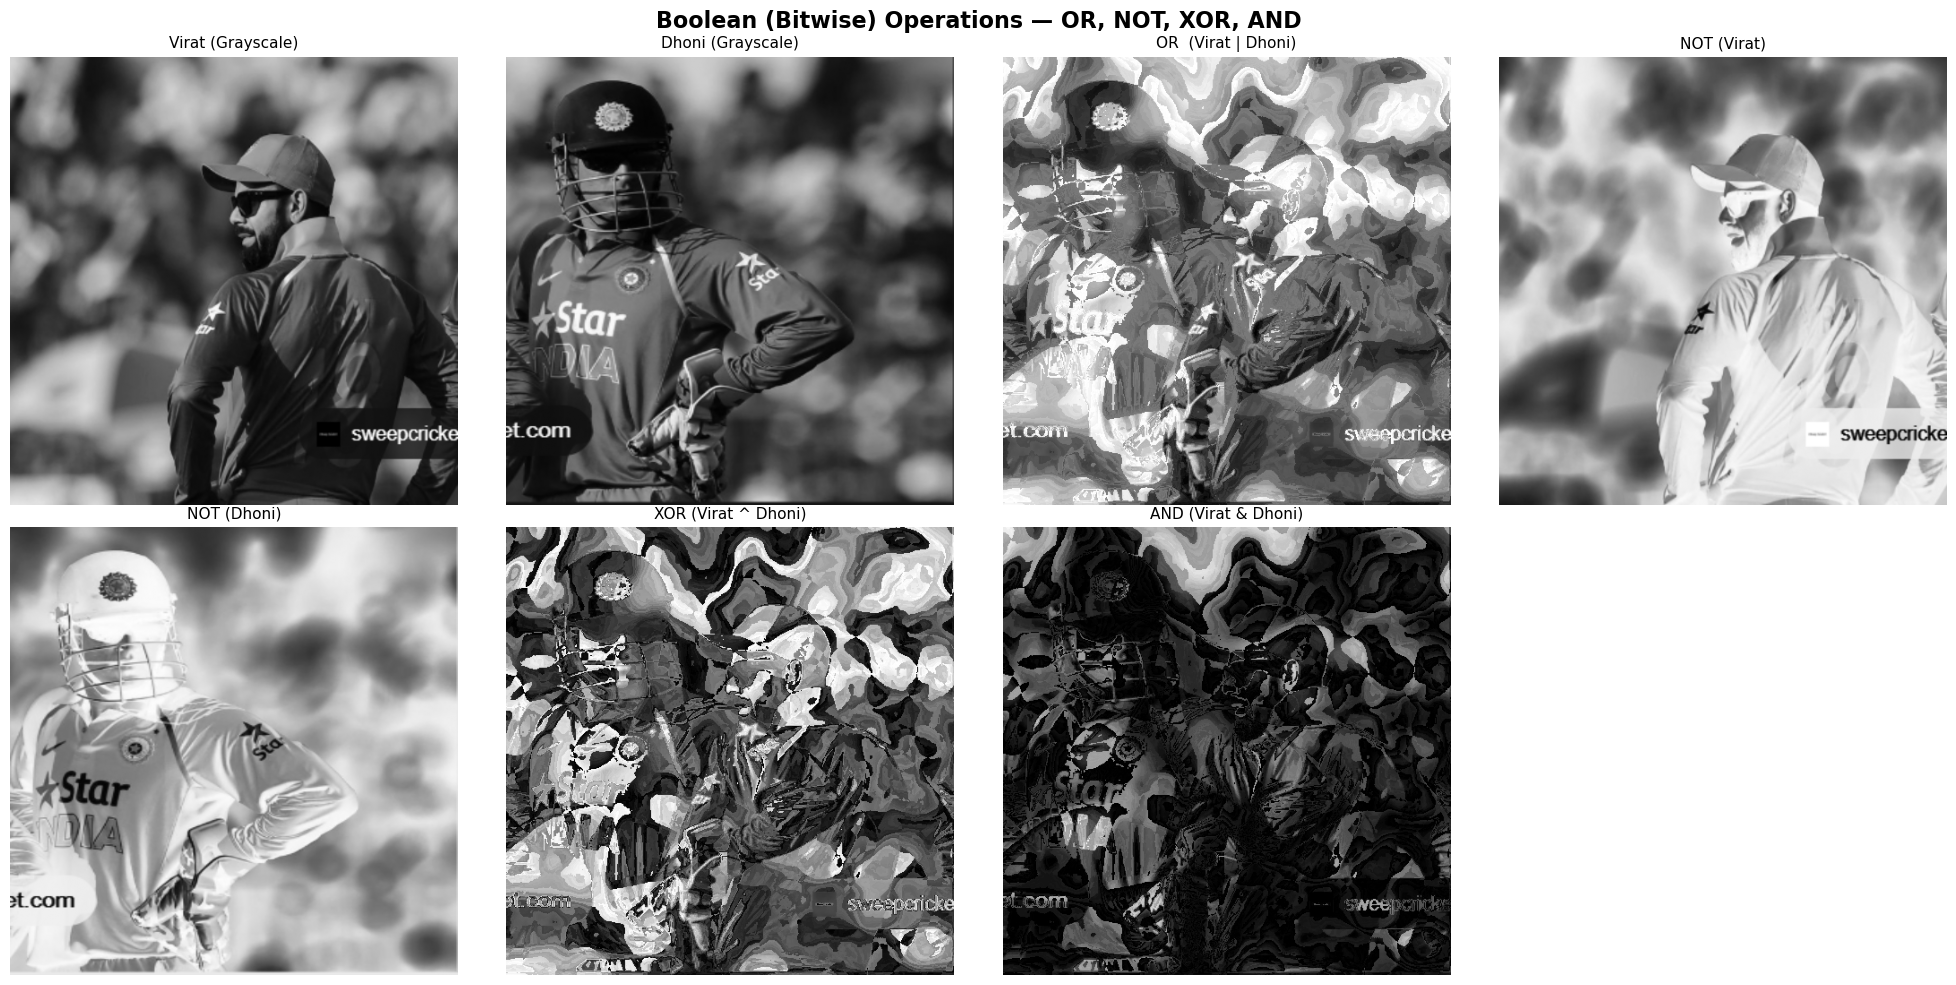

Pixel Value Example (single pixel at position [100,100]):
Virat  pixel : 38  → binary: 00100110
Dhoni  pixel : 25  → binary: 00011001
OR     result: 63  → binary: 00111111
NOT    result: 217  → binary: 11011001
XOR    result: 63  → binary: 00111111
AND    result: 0  → binary: 00000000


In [10]:
# ============================================================
# CELL 8: Boolean (Bitwise) Operations
# ============================================================
# Boolean operations work on binary (bit-level) representation
# of each pixel value (0-255 converted to 8-bit binary)
#
# Example (single pixel):
# Virat pixel  = 200 → binary: 11001000
# Dhoni pixel  = 150 → binary: 10010110
# OR  result   = 222 → binary: 11011110
# NOT (virat)  =  55 → binary: 00110111
# XOR result   =  94 → binary: 01011110
# AND result   = 128 → binary: 10000000
# ============================================================

# Convert to grayscale for cleaner boolean operation results
virat_gray = cv2.cvtColor(virat_resized, cv2.COLOR_BGR2GRAY)
dhoni_gray = cv2.cvtColor(dhoni_resized, cv2.COLOR_BGR2GRAY)

# ── OR Operation ──
# Result pixel is bright if EITHER image has a bright pixel
# Combines features from both images
bitwise_or = cv2.bitwise_or(virat_gray, dhoni_gray)

# ── NOT Operation ──
# Flips every bit — inverts the image completely
# Bright areas become dark, dark areas become bright
# NOT is a unary operation — applied to one image at a time
bitwise_not_virat = cv2.bitwise_not(virat_gray)
bitwise_not_dhoni = cv2.bitwise_not(dhoni_gray)

# ── XOR Operation ──
# Result pixel is bright where the two images DIFFER
# Dark where both images are similar
# Useful for detecting differences between two images
bitwise_xor = cv2.bitwise_xor(virat_gray, dhoni_gray)

# ── AND Operation ──
# Result pixel is bright ONLY where BOTH images are bright
# Keeps only the common features between two images
bitwise_and = cv2.bitwise_and(virat_gray, dhoni_gray)

# ============================================================
# Display All Boolean Operations in One Figure
# ============================================================
results = {
    "Virat (Grayscale)"   : virat_gray,
    "Dhoni (Grayscale)"   : dhoni_gray,
    "OR  (Virat | Dhoni)" : bitwise_or,
    "NOT (Virat)"         : bitwise_not_virat,
    "NOT (Dhoni)"         : bitwise_not_dhoni,
    "XOR (Virat ^ Dhoni)" : bitwise_xor,
    "AND (Virat & Dhoni)" : bitwise_and,
}

plt.figure(figsize=(20, 10))

for i, (title, img) in enumerate(results.items()):
    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(title, fontsize=11)
    plt.axis('off')

plt.suptitle("Boolean (Bitwise) Operations — OR, NOT, XOR, AND",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print pixel value examples to understand bit-level operations ──
print("=" * 55)
print("Pixel Value Example (single pixel at position [100,100]):")
print("=" * 55)
print(f"Virat  pixel : {virat_gray[100,100]}  → binary: {format(virat_gray[100,100], '08b')}")
print(f"Dhoni  pixel : {dhoni_gray[100,100]}  → binary: {format(dhoni_gray[100,100], '08b')}")
print(f"OR     result: {bitwise_or[100,100]}  → binary: {format(bitwise_or[100,100], '08b')}")
print(f"NOT    result: {bitwise_not_virat[100,100]}  → binary: {format(bitwise_not_virat[100,100], '08b')}")
print(f"XOR    result: {bitwise_xor[100,100]}  → binary: {format(bitwise_xor[100,100], '08b')}")
print(f"AND    result: {bitwise_and[100,100]}  → binary: {format(bitwise_and[100,100], '08b')}")